Dataset shape: (1200, 14)

Column names:
['Timestamp', 'Plant_ID', 'Soil_Moisture', 'Ambient_Temperature', 'Soil_Temperature', 'Humidity', 'Light_Intensity', 'Soil_pH', 'Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level', 'Chlorophyll_Content', 'Electrochemical_Signal', 'Plant_Health_Status']

Data types:
Soil_Moisture                 float64
humidity_stress               float64
moisture_temp_interaction     float64
light_moisture_interaction    float64
Plant_Health_Status               str
dtype: object

Missing values per required column:
Soil_Moisture                 0
humidity_stress               0
moisture_temp_interaction     0
light_moisture_interaction    0
Plant_Health_Status           0
dtype: int64

Duplicate rows in original dataset: 0

Shape after dropping missing values: (1200, 5)
Rows removed due to missing values: 0

Sample of cleaned dataset:
      Soil_Moisture  humidity_stress  moisture_temp_interaction  \
1140      10.785187         4.531201                 23

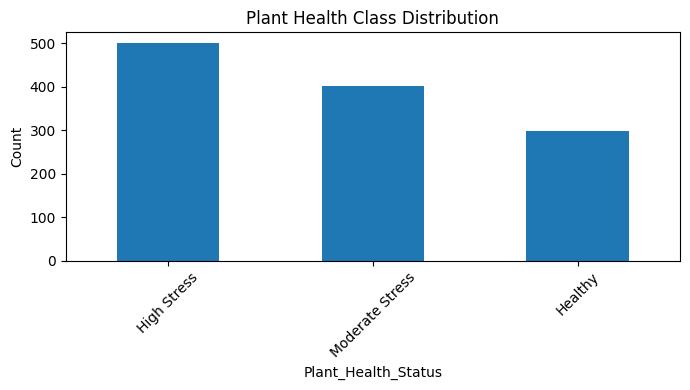


Accuracy:
Train accuracy: 1.0000
Test accuracy:  0.8417

Accuracy:
Train accuracy: 1.0000
Test accuracy:  0.8417
Train set report:
                 precision    recall  f1-score   support

        Healthy       1.00      1.00      1.00       239
    High Stress       1.00      1.00      1.00       400
Moderate Stress       1.00      1.00      1.00       321

       accuracy                           1.00       960
      macro avg       1.00      1.00      1.00       960
   weighted avg       1.00      1.00      1.00       960

Test set report:
                 precision    recall  f1-score   support

        Healthy       0.73      0.98      0.84        60
    High Stress       0.99      0.73      0.84       100
Moderate Stress       0.82      0.88      0.85        80

       accuracy                           0.84       240
      macro avg       0.85      0.86      0.84       240
   weighted avg       0.87      0.84      0.84       240



<Figure size 600x600 with 0 Axes>

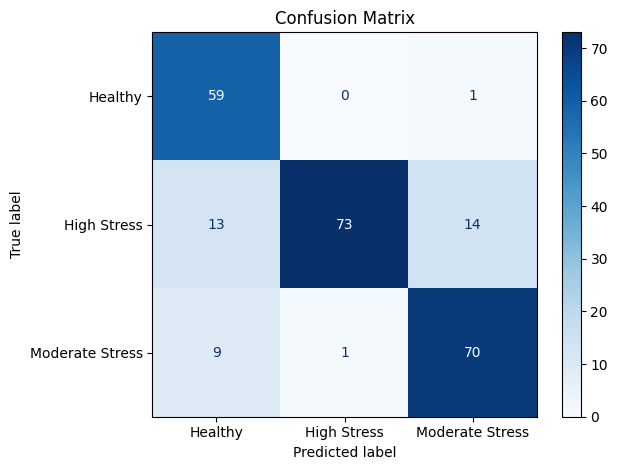

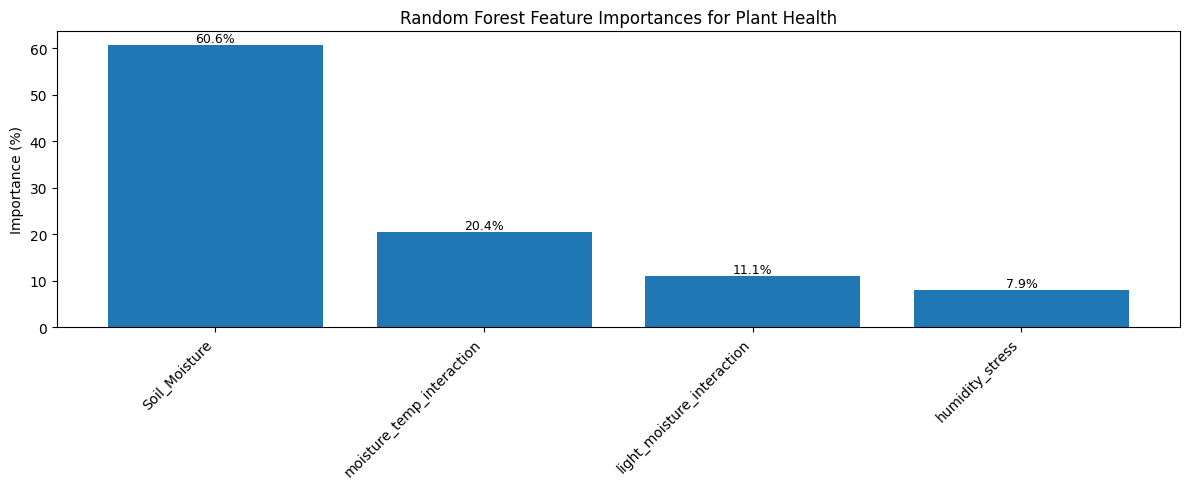


SHAP value shape: (240, 4, 3)

SHAP stats:
Mean SHAP: 0.09791458726138928
Max SHAP:  0.5498999920103234

Global SHAP feature importance:
                      feature  mean_abs_shap
0               Soil_Moisture       0.303051
2   moisture_temp_interaction       0.050549
1             humidity_stress       0.021093
3  light_moisture_interaction       0.016965

Showing SHAP beeswarm for class index: 0


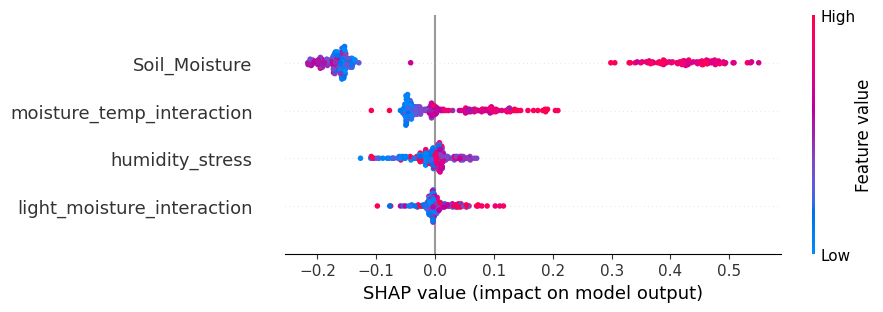


Showing SHAP beeswarm for class index: 1


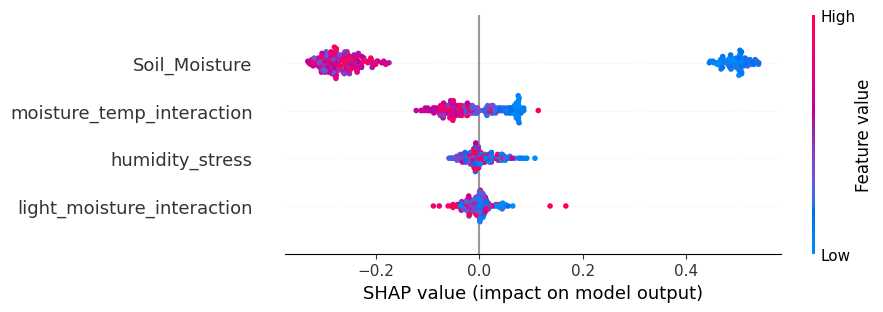


Showing SHAP beeswarm for class index: 2


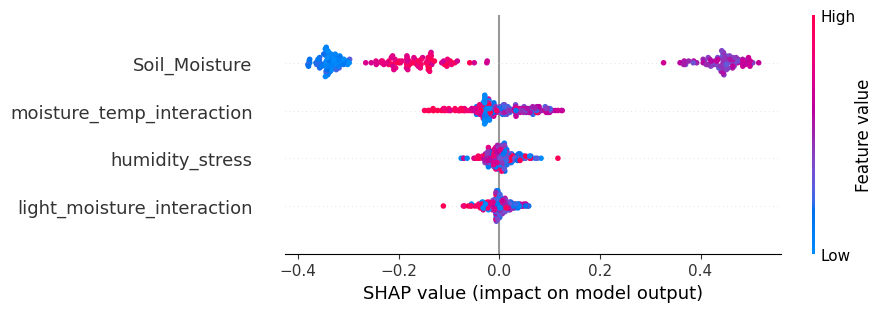

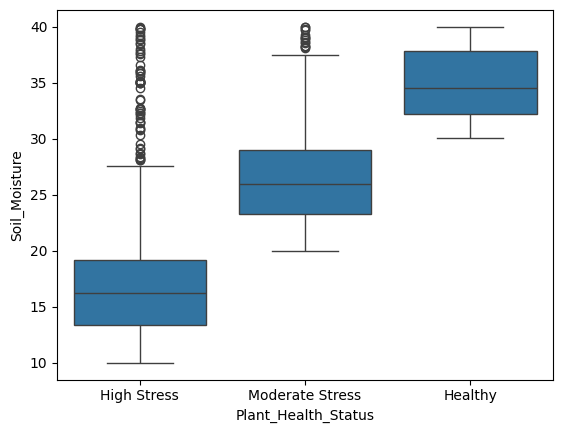


Sample test results:
      Soil_Moisture  humidity_stress  moisture_temp_interaction  \
1003      35.276253        18.334839                 676.360870   
726       20.712396         8.870249                 429.028302   
515       34.078704        17.700105                 960.019543   
1163      37.819297        18.993041                1108.606501   
431       39.356260         5.375253                 768.502341   

      light_moisture_interaction           Actual        Predicted  
1003                33762.855008          Healthy          Healthy  
726                 17907.143152  Moderate Stress  Moderate Stress  
515                  7659.977249          Healthy          Healthy  
1163                28588.644193          Healthy          Healthy  
431                 21909.770876          Healthy          Healthy  

Dataset Validation Summary
--------------------------
Original rows: 1200
Rows used after cleaning: 1200
Features used: ['Soil_Moisture', 'humidity_stress', 'mo

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
import seaborn as sns

data = pd.read_csv("../../../datasets/plant_health_data.csv")

print("Dataset shape:", data.shape)
print("\nColumn names:")
print(data.columns.tolist())

target_column = 'Plant_Health_Status'

# Can be depended based upon plant preference on soil moisture
ideal_humidity = 60

data['humidity_stress'] = (data['Humidity'] - ideal_humidity).abs()

data['moisture_temp_interaction'] = (
    data['Soil_Moisture'] * data['Ambient_Temperature']
)

data['light_moisture_interaction'] = (
    data['Light_Intensity'] * data['Soil_Moisture']
)

feature_columns = [
    'Soil_Moisture',

    'humidity_stress',
    'moisture_temp_interaction',
    'light_moisture_interaction'
]

required_columns = feature_columns + [
    target_column,
]

missing_columns = [col for col in required_columns if col not in data.columns]
if missing_columns:
    raise ValueError(f"Dataset is missing required columns: {missing_columns}")

print("\nData types:")
print(data[required_columns].dtypes)

print("\nMissing values per required column:")
print(data[required_columns].isnull().sum())

print("\nDuplicate rows in original dataset:", data.duplicated().sum())

dataset_columns = feature_columns + [target_column]

dataset = data[dataset_columns].copy()

before_drop = len(dataset)
dataset = dataset.dropna()
after_drop = len(dataset)

print("\nShape after dropping missing values:", dataset.shape)
print("Rows removed due to missing values:", before_drop - after_drop)

print("\nSample of cleaned dataset:")
print(dataset.sample(min(5, len(dataset))))

print("\nTarget class distribution:")
print(dataset[target_column].value_counts())

dataset[target_column].value_counts().plot(kind='bar', figsize=(7, 4))
plt.title("Plant Health Class Distribution")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

x = dataset[feature_columns]
y = dataset[target_column]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(random_state=42)
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

train_predictions = model.predict(x_train)
test_predictions = model.predict(x_test)
train_predictions = model.predict(x_train)
test_predictions = model.predict(x_test)

train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)

print("\nAccuracy:")
print(f"Train accuracy: {train_accuracy:.4f}")
print(f"Test accuracy:  {test_accuracy:.4f}")

print("\nAccuracy:")
print(f"Train accuracy: {train_accuracy:.4f}")
print(f"Test accuracy:  {test_accuracy:.4f}")

print("Train set report:")
train_predictions = model.predict(x_train)
print(classification_report(y_train, train_predictions))

print("Test set report:")
test_predictions = model.predict(x_test)
print(classification_report(y_test, test_predictions))

class_labels = sorted(y.unique())

cm = confusion_matrix(y_test, test_predictions, labels=class_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

plt.figure(figsize=(6, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

importances = model.feature_importances_
feature_names = X.columns
importances_pct = importances * 100

indices = np.argsort(importances_pct)[::-1]

plt.figure(figsize=(12, 5))
bars = plt.bar(range(len(importances_pct)), importances_pct[indices])

plt.xticks(
    range(len(importances_pct)),
    feature_names[indices],
    rotation=45,
    ha='right'
)

plt.ylabel("Importance (%)")
plt.title("Random Forest Feature Importances for Plant Health")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

explainer = shap.Explainer(model, x_train)
shap_values = explainer(x_test)

print("\nSHAP value shape:", shap_values.values.shape)

mean_shap = np.abs(shap_values.values).mean()
max_shap = np.abs(shap_values.values).max()

print("\nSHAP stats:")
print(f"Mean SHAP: {mean_shap}")
print(f"Max SHAP:  {max_shap}")

global_importance = np.abs(shap_values.values).mean(axis=(0, 2))

importance_df = pd.DataFrame({
    "feature": x_test.columns,
    "mean_abs_shap": global_importance
}).sort_values("mean_abs_shap", ascending=False)

print("\nGlobal SHAP feature importance:")
print(importance_df)

num_classes = shap_values.values.shape[2]

for class_idx in range(num_classes):
    print(f"\nShowing SHAP beeswarm for class index: {class_idx}")
    shap.plots.beeswarm(shap_values[..., class_idx])

test_results = x_test.copy()
test_results['Actual'] = y_test.values
test_results['Predicted'] = test_predictions

sns.boxplot(x='Plant_Health_Status', y='Soil_Moisture', data=dataset)
plt.show()

print("\nSample test results:")
print(test_results.head())

print("\nDataset Validation Summary")
print("--------------------------")
print(f"Original rows: {len(data)}")
print(f"Rows used after cleaning: {len(dataset)}")
print(f"Features used: {feature_columns}")
print(f"Target classes: {sorted(y.unique().tolist())}")
print(f"Missing values removed: {before_drop - after_drop}")
print(f"Duplicate rows in original data: {data.duplicated().sum()}")
print(f"Train accuracy: {train_accuracy:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print("\nTop SHAP features:")
print(importance_df.head(10).to_string(index=False))